# GSB 5544 — PA 4.1: Text Data — Spam Emails — SOLUTION

In this activity you'll work with a small sample from the [Enron email corpus](https://en.wikipedia.org/wiki/Enron_Corpus). The [data set we'll use](https://raw.githubusercontent.com/kevindavisross/data301/refs/heads/main/data/enron_email.csv) contains the subjects and bodies of a sample of e-mails that the Federal Energy Regulatory Commission (FERC) collected during their 2002 investigation of the energy company [Enron](https://en.wikipedia.org/wiki/Enron). Each row in the data set is an email and there are three columns

- subject: the subject of the email
- body: the text of the email
- spam: spam indicator, 1 if spam, 0 if not

For this activity we will only consider the body of the emails (though you could also include the subject using similar methods).

1\. The corpus is the body column in the [data set](https://raw.githubusercontent.com/kevindavisross/data301/refs/heads/main/data/enron_email.csv); read this column in to create the corpus.


In [1]:
import pandas as pd
import numpy as np

emails = pd.read_csv("https://raw.githubusercontent.com/kevindavisross/data301/refs/heads/main/data/enron_email.csv")
emails

,subject,body,spam
0,mirant 4 / 01,we invoiced mirant americas for deal 705989 an...,0.0
1,re : lobo payout,because the payback was done for october 2001 ...,0.0
2,entex transaction 7,"for december 1999 , since the volumes for tran...",0.0
3,re : hpl transport contracts,i would think that the first contract should g...,0.0
4,welcome to aol instant messenger !,welcome to the aol instant messenger ( sm ) se...,0.0
...,...,...,...
1985,customer reciept # 4359 bn winkle,simply visti our site and let ' s see if we ca...,NaN
1986,internet pharmacy - smart prices,order your medication here - no doctor visit n...,NaN
1987,victory at last,"wed , 09 jun 2004 13 : 33 : 18 - 0300\nsir or ...",NaN
1988,free pay per view,had chance at last to view the warner bros . l...,NaN


In [2]:
# The corpus is the collection of documents: one email body per document.
# A few dozen bodies are missing (NaN) — CountVectorizer refuses NaN documents,
# so replace them with the empty string before vectorizing.
emails["body"].isna().sum()

np.int64(61)

In [3]:
corpus = emails["body"].fillna("")
corpus

0       we invoiced mirant americas for deal 705989 an...
1       because the payback was done for october 2001 ...
2       for december 1999 , since the volumes for tran...
3       i would think that the first contract should g...
4       welcome to the aol instant messenger ( sm ) se...
                              ...                        
1985    simply visti our site and let ' s see if we ca...
1986    order your medication here - no doctor visit n...
1987    wed , 09 jun 2004 13 : 33 : 18 - 0300\nsir or ...
1988    had chance at last to view the warner bros . l...
1989    while example milk . water , own , make , wire...
Name: body, Length: 1990, dtype: str

**Answer:** 1,990 emails. The corpus is the `body` column; 61 bodies are missing, and since
`CountVectorizer` raises an error on `NaN` documents we treat a missing body as an
empty document with `.fillna("")` (an empty document simply gets a row of zeros).

2\. Describe in words in detail the steps that you would take to clean the emails and create the term-frequency matrix. We will write the code in the next part, but think carefully first about the process: how do we turn this text into tabular data?


**Answer:** to turn the pile of email bodies into tabular data:

1. **Normalize the text** — lowercase every document, so `Free`, `free`, and `FREE` count as the same word.
2. **Tokenize** — split each document into individual words (*tokens*), treating punctuation and whitespace as separators (so `prize!` and `prize` are the same token).
3. **Build the vocabulary** — collect the set of distinct words appearing anywhere in the corpus. Each distinct word becomes a **column**.
4. **Count** — for each email (row) and each vocabulary word (column), record how many times that word appears in that email. These counts are the **term frequencies**.

The result is the **term-frequency (TF) matrix**: one row per email, one column per word,
counts in the cells — text is now a data frame. (Optional refinements at each step: drop
very common "stop words", strip word endings/stemming, only keep words above a minimum
document frequency — `CountVectorizer` has options for all of these, but the defaults are
fine here.)

3\. Use `CountVectorizer` to create the TF matrix, and then convert it to a pandas data frame with appropriate column names. You can just use the defaults in `CountVectorizer`. Hint: this should pretty much be a straight copy of code from the reading, but make sure you understand the process behind the code.


In [4]:
from sklearn.feature_extraction.text import CountVectorizer

vec = CountVectorizer()
tf = vec.fit_transform(corpus)                       # learn vocabulary, then count
tf_df = pd.DataFrame(tf.toarray(), columns=vec.get_feature_names_out())
tf_df

,00,000,0000,000000,000000000002858,000000000049773,000080,0001,00020608,0004,...,zyban,zykfe,zyl,zynsdirnh,zynve,zyqtaqlt,zyyqywp,zzezrjok,zzo,zzso
0,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1985,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
1986,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1987,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1988,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


**Answer:** 1,990 rows (one per email) by ~35,000 columns (one per distinct word in the corpus).
`fit_transform` learns the vocabulary and produces a sparse count matrix; `.toarray()`
plus `get_feature_names_out()` turn it into a regular data frame with words as
column names.

4\. Explain what a document frequency (DF) is, and the idea of an IDF. Why might we use TF-IDF rather than just TF? This question is asking about concepts rather than computations.


**Answer:**

- The **document frequency (DF)** of a word is the number (or fraction) of *documents in the corpus* that contain the word — not how often it appears within any one document. `the` has a DF near 1,990 here; `pharmacy` has a small DF.
- The **inverse document frequency (IDF)** flips this into a weight, roughly `log(number of documents / DF)`: near zero for a word that appears in almost every document, large for a rare word. **TF-IDF** multiplies each term frequency by its word's IDF.
- **Why TF-IDF rather than TF:** raw counts are dominated by exactly the words that carry the least information. Every email uses `the`, `to`, and `and` a lot, so with raw TF two emails look "similar" mostly because they are both written in English. Words that appear in only a few documents — `viagra`, `invoice`, `nomination` — are what actually distinguish one email from another, and TF-IDF boosts them while flattening the everywhere-words. When we later measure similarity between emails, TF-IDF makes the comparison depend on the *distinctive* vocabulary rather than the filler.

5\. Use `TfidfVectorizer` to create the TF matrix, and then convert it to a pandas data frame with appropriate column names. You can just use the defaults in `TfidfVectorizer`. Hint: this should pretty much be a straight copy of code from the reading, but make sure you understand the process behind the code.

In [5]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vec = TfidfVectorizer()
tfidf = tfidf_vec.fit_transform(corpus)
tfidf_df = pd.DataFrame(tfidf.toarray(), columns=tfidf_vec.get_feature_names_out())
tfidf_df

,00,000,0000,000000,000000000002858,000000000049773,000080,0001,00020608,0004,...,zyban,zykfe,zyl,zynsdirnh,zynve,zyqtaqlt,zyyqywp,zzezrjok,zzo,zzso
0,0.0,0.106624,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00000,0.0
1,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00000,0.0
2,0.0,0.097060,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00000,0.0
3,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00000,0.0
4,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00000,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1985,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.11587,0.0
1986,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00000,0.0
1987,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00000,0.0
1988,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00000,0.0


**Answer:** Same shape as the TF matrix, but each entry is now the term frequency weighted by the
word's IDF (and each row is normalized to unit length by default), so common-everywhere
words are shrunk toward zero and distinctive words stand out.

6\. Remember that the data set also contains an indicator of whether or not the email is spam. In this part you will use descriptive statistics and plots to compare the spam and non-spam emails in terms of their text, represented by the TF and TF-IDF matrices. This part is pretty open ended. First brainstorm some questions or things to investigate, and then write the code to produce relevant summaries.

Note: there are 10 emails for which the spam indicator is missing. You should remove them for this part. We'll come back to them soon.


**Brainstormed questions.** (Yours may differ — that is the point of an open-ended part.)

1. Are spam emails *longer or shorter* than non-spam emails?
2. Which words does each class use most (by average TF)?
3. Which words *separate* the classes best (biggest gap in average TF-IDF)?

In [6]:
# Keep only the emails with a known spam label for this part
known = emails["spam"].notna()
spam = emails.loc[known, "spam"]

tf_known = tf_df[known]
tfidf_known = tfidf_df[known]
spam.value_counts()

spam
0.0    995
1.0    985
Name: count, dtype: int64

In [7]:
# Q1: email length — total word count is the row sum of the TF matrix
tf_known.sum(axis=1).groupby(spam).describe().round(1)

,count,mean,std,min,25%,50%,75%,max
spam,,,,,,,,
0.0,995.0,135.3,181.6,0.0,28.0,74.0,174.5,1833.0
1.0,985.0,176.2,271.3,0.0,36.0,74.0,180.0,2594.0


In [8]:
# Q2: most-used words in each class, by average term frequency
mean_tf = tf_known.groupby(spam).mean()
pd.DataFrame({
    "top not-spam (0)": mean_tf.loc[0.0].sort_values(ascending=False).head(10).index,
    "top spam (1)":     mean_tf.loc[1.0].sort_values(ascending=False).head(10).index,
})

,top not-spam (0),top spam (1)
0,the,the
1,to,to
2,ect,and
3,and,of
4,hou,in
5,for,you
6,enron,for
7,on,this
8,of,is
9,this,your


In [9]:
# Q3: the words with the biggest gap in average TF-IDF between the classes
mean_tfidf = tfidf_known.groupby(spam).mean()
gap = mean_tfidf.loc[1.0] - mean_tfidf.loc[0.0]     # positive -> spam-leaning

leaning = pd.concat([gap.sort_values().head(10), gap.sort_values().tail(10)]).reset_index()
leaning.columns = ["word", "gap"]
leaning["leans"] = np.where(leaning["gap"] > 0, "spam", "not spam")
leaning

,word,gap,leans
0,ect,-0.075333,not spam
1,enron,-0.051935,not spam
2,xls,-0.040757,not spam
3,hou,-0.040711,not spam
4,hpl,-0.034787,not spam
5,000,-0.032758,not spam
6,2000,-0.031354,not spam
7,attached,-0.029854,not spam
8,deal,-0.028976,not spam
9,gas,-0.026951,not spam


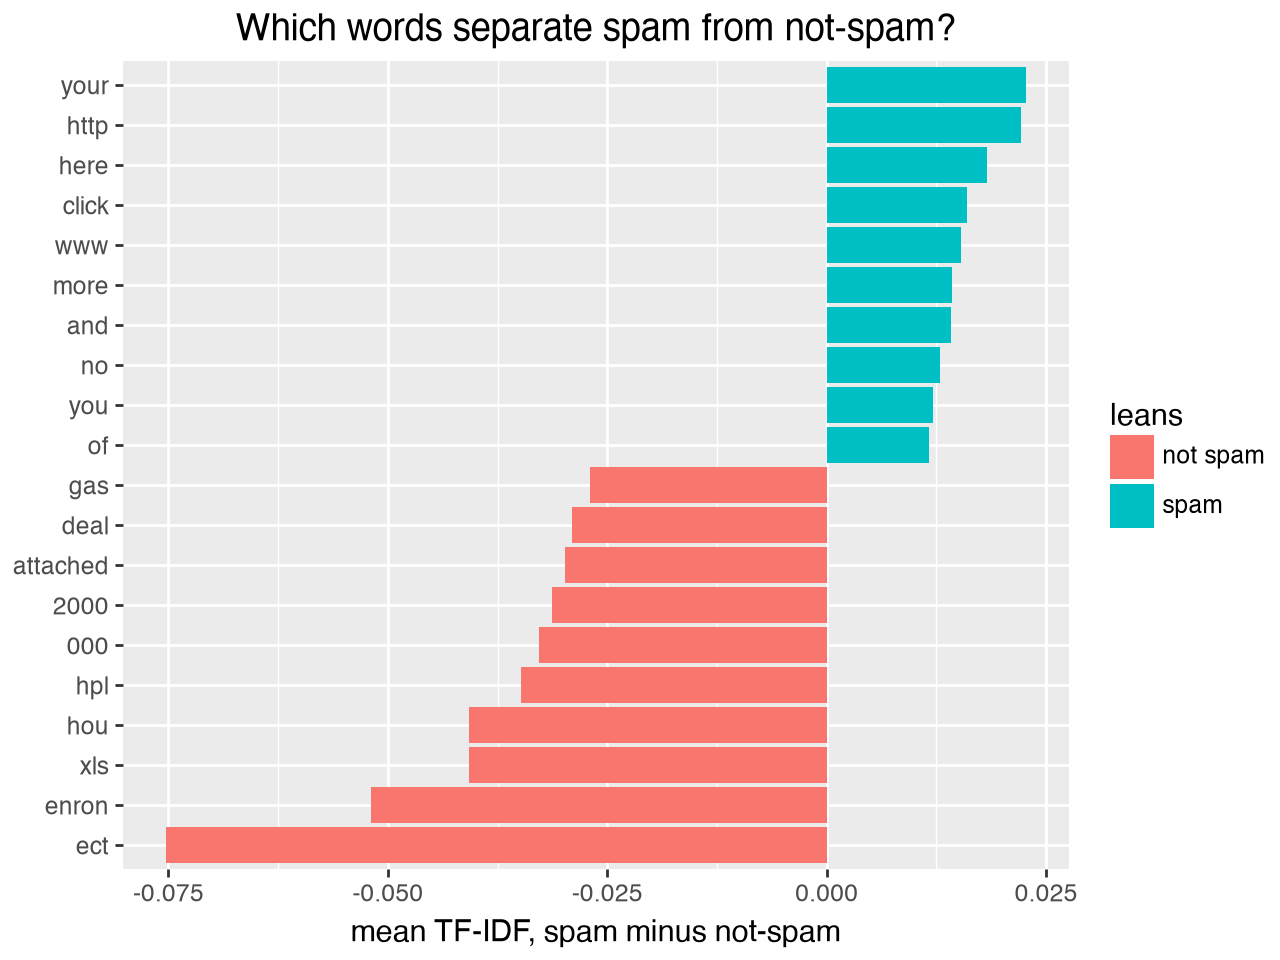

In [10]:
from plotnine import ggplot, aes, geom_col, coord_flip, labs

(ggplot(leaning, aes(x="reorder(word, gap)", y="gap", fill="leans"))
 + geom_col()
 + coord_flip()
 + labs(x="", y="mean TF-IDF, spam minus not-spam",
        title="Which words separate spam from not-spam?"))

**Answer:** Spam emails run **longer** on average (mean ≈ 176 words vs ≈ 135, with a much heavier tail).
By raw average TF both classes are topped by filler (`the`, `to`, `and`) — exactly the
raw-count problem from part 4. The TF-IDF gap is far more interpretable: the not-spam side
is dominated by Enron business vocabulary (`ect`, `enron`, `hou`, `xls`, `hpl`, `attached`,
`2000` — mail routing codes, spreadsheet attachments, deal talk), while the spam side is
marketing language (`your`, `http`, `here`, `click`, `www`, `free`). Spam talks *at you*
and wants a click; work email talks about *the business*.

7\. Now consider the 10 emails for which the true spam status is unknown. How might you decide if each email is spam or not? Brainstorm some ideas before proceeding. How can you use the TF and TF-IDF matrices for emails with known spam status?

**Answer:** ideas that use what we have built:

- **Look for spam-y words** — from part 6 we know words like `click`, `http`, `free` lean spam and `enron`, `hou`, `attached` lean not-spam; we could score each unknown email by which side of the vocabulary it uses.
- **Nearest neighbours (the approach we take below):** the TF / TF-IDF matrices put every email — known and unknown — in the *same* columns, so we can compute the **distance** between an unknown email and every labelled email. If the emails most similar to the unknown one are overwhelmingly spam, guess spam; if they are overwhelmingly legitimate, guess not-spam. Because email lengths vary wildly, **cosine distance** (which compares the *mix* of words, ignoring document length) is the right ruler — this is exactly Week 3's "find the most similar rows", with columns we built ourselves.

8\. Consider just one email with unknown spam status, with `loc` 1980. Compute the cosine distance between the TF representation of this email and the TF representation of each of the emails with known spam status.

In [11]:
from sklearn.metrics.pairwise import cosine_similarity

emails.loc[1980, "body"]

'dear jerry ,\nthank you for requesting more information from quicken loans through our\nwebsite . we are excited to have this chance to demonstrate our world - class\ncustomer service to you .\ni made an initial attempt to contact you to gather the additional information\nrequired to process your application but have not been able to get through .\nplease reply to this message with the best time to call and the phone number\nyou would like me to use .\nif it is more convenient , you can also call me direct at 800 . 226 . 6308 ext .\n57531 . our phone lines are open monday - thursday , 8 : 00 am - 9 : 00 pm , friday ,\n8 : 00 am - 7 : 00 pm and saturday , 10 : 00 am - 4 : 00 pm ( all times eastern ) . if i\nam not available , one of the other loan consultants on my team will be happy\nto assist you .\ninterest rates change daily . for the latest rates on our many programs you\ncan call anytime . i look forward to working with you to complete your\napplication .\nsincerely ,\ndaniel jen

In [12]:
# cosine distance = 1 - cosine similarity, from email 1980 to every labelled email
sims = cosine_similarity(tf_df.loc[[1980]], tf_df[known])[0]
dist_tf = pd.Series(1 - sims, index=emails.index[known], name="cosine_dist_tf")
dist_tf

0       0.736928
1       0.542990
2       0.775802
3       0.653954
4       0.519088
          ...   
1975    0.944996
1976    0.649040
1977    0.448669
1978    0.693219
1979    0.931826
Name: cosine_dist_tf, Length: 1980, dtype: float64

9\. Sort the results of the previous part to examine the emails with known spam status that are most similar to the unknown email. If you had to determine if the unknown email was spam or not, which would you pick and why?

In [13]:
nearest_tf = dist_tf.sort_values().head(10)
pd.DataFrame({"cosine_dist_tf": nearest_tf.round(3),
              "spam": emails.loc[nearest_tf.index, "spam"].astype(int),
              "subject": emails.loc[nearest_tf.index, "subject"]})

,cosine_dist_tf,spam,subject
1889,0.393,1,please update your account details with citibank
1032,0.398,1,can you facilitate ?
1376,0.409,1,from dr kenneth
714,0.415,0,75 th anniversary celebration
1110,0.416,1,my site links to your site now
26,0.419,0,re : tglo status
180,0.423,0,fw : waha hubco
879,0.425,0,dallas june hoop - it - up is coming to town !
713,0.428,0,fw : hpl imbalance payback
139,0.435,0,re : tglo status


**Answer:** Email 1980 is a *"thank you for requesting more information from quicken loans"*
marketing message. Of its 10 nearest labelled emails by TF cosine distance, the large
majority are spam (and the closest ones are other loan/marketing pitches), so I would
call it **spam (1)**. The reasoning: emails that use the same mix of words as known
spam are, absent other evidence, most plausibly spam themselves.

10\. Repeat the two previous parts using TF-IDF instead of TF. Do the results change?

In [14]:
sims = cosine_similarity(tfidf_df.loc[[1980]], tfidf_df[known])[0]
dist_tfidf = pd.Series(1 - sims, index=emails.index[known], name="cosine_dist_tfidf")

nearest_tfidf = dist_tfidf.sort_values().head(10)
pd.DataFrame({"cosine_dist_tfidf": nearest_tfidf.round(3),
              "spam": emails.loc[nearest_tfidf.index, "spam"].astype(int),
              "subject": emails.loc[nearest_tfidf.index, "subject"]})

,cosine_dist_tfidf,spam,subject
1032,0.755,1,can you facilitate ?
1977,0.781,1,reply soon ! ! !
48,0.788,0,tetco / hpl ( enerfin ) meter # 986892
1689,0.790,1,how are you today ?
1796,0.795,1,urgent assistance
180,0.797,0,fw : waha hubco
586,0.799,0,re : entex volumes
1376,0.799,1,from dr kenneth
279,0.800,0,enron files chapter 11 reorganization
1021,0.801,1,urgent reply


**Answer:** The distances themselves grow (TF-IDF zeroes out the shared filler words, so overlaps are
rarer and everything sits further apart) and the exact neighbour list shuffles — the
TF-IDF neighbours match on *distinctive* loan-marketing words rather than on generic
vocabulary. But the **verdict is unchanged**: the nearest emails are still mostly spam,
so email 1980 is still classified spam. When both rulers agree, that is reassuring.

11\. Now proceed in a similar manner to "guess" the spam status of each of the unknown emails.

In [15]:
unknown = emails.index[emails["spam"].isna()]

def nn_vote(i, X, k=5):
    """Fraction of email i's k nearest labelled neighbours (cosine distance) that are spam."""
    sims = cosine_similarity(X.loc[[i]], X[known])[0]
    dist = pd.Series(1 - sims, index=emails.index[known])
    return emails.loc[dist.sort_values().head(k).index, "spam"].mean()

guesses = pd.DataFrame({
    "subject": emails.loc[unknown, "subject"],
    "frac_spam_tf": [nn_vote(i, tf_df) for i in unknown],
    "frac_spam_tfidf": [nn_vote(i, tfidf_df) for i in unknown],
})
guesses["guess"] = np.where(guesses["frac_spam_tfidf"] >= 0.5, "spam", "not spam")
guesses

,subject,frac_spam_tf,frac_spam_tfidf,guess
1980,let ' s talk about your home loan .,0.8,0.8,spam
1981,intraday eastrans nomination change for 9 / 6 ...,0.0,0.0,not spam
1982,"frontrea plant , gas",0.4,0.2,not spam
1983,re : meter 5892,0.0,0.0,not spam
1984,eastrans nomination change effective 8 / 3 / 00,0.0,0.0,not spam
1985,customer reciept # 4359 bn winkle,0.6,0.8,spam
1986,internet pharmacy - smart prices,1.0,1.0,spam
1987,victory at last,1.0,1.0,spam
1988,free pay per view,1.0,1.0,spam
1989,87 % off for all new software . darned canniba...,0.4,0.4,not spam


**Answer:** For each unknown email we take a **majority vote of its 5 nearest labelled neighbours** by
cosine distance. TF and TF-IDF agree on every email: **1980, 1985, 1986, 1987, 1988 → spam**
(loan marketing, a fake "receipt", an internet pharmacy, "victory at last", "free pay per
view") and **1981–1984, 1989 → not spam** (the eastrans nomination and meter emails are
unmistakably Enron gas-scheduling traffic). The interesting case is **1989** — the subject
(*"87% off for all new software"*) screams spam, but its body is stuffed with random dictionary
words to fool word-count filters, so its 5-neighbour vote is only 0.4 and the body-only
classifier narrowly calls it not-spam. A good reminder that the guess depends on our choices:
including the `subject` text, using a different k, or weighting votes by distance could all
flip a borderline case.